<a href="https://colab.research.google.com/github/JannatL/Quiz4_Mortgages/blob/main/Quiz_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Quiz 4: Mortgage Approval Model

####by Jannat Lily

##**Introduction**

Mortgage lending in the U.S. has a contravesial history involving reedlining, which is a practice where banks auto rejected loans for homes located in areas where residents were proven to default more often. This practice is now illegal under the federal law, but accusations of racial bias in the mortgage lending industry presist.

Our goal in this project is to create a model that can predict whether or not a given mortgage loan application is likely to be approved or denied, so that we can identify which features significantly influence denial decisions. This should allow use to objectively determine whether or not racial bias exists in the approval process. We will create three models and choose the best one for the task.

We will pull data from the Federal Reserve Bank of Boston that contains information on 2,381 mortgage applications. The response variable is **DENY** and there are twelve predictors that contribute to the decison to deny or reject a loan.

- Dependent Variable: **DENY** is a binary variable and indicates whether a mortgage application was denied (yes = 1) or accepted (no = 0)

- The 12 independent variables:

  - **dir**: *Debt-to-Income Ratio*
      - Applicant’s total debt payments divided by total income (continuous)

  - **hir**: *Housing-to-Income Ratio*  
    - Monthly housing expenses divided by monthly income (continuous)

  - **lvr**: *Loan-to-Value Ratio*  
    - Loan amount divided by the assessed value of the property (continuous)

  - **ccs**: *Consumer Credit Score*  
    - Scale from 1 to 6; lower values indicate better credit (ordinal)

  - **mcs**: *Mortgage Credit Score*  
    - Scale from 1 to 4; lower values indicate better mortgage credit (ordinal)

  - **pbcr**: *Public Bad Credit Record*  
    - Binary: 1 = Applicant has a public bad credit record; 0 = No (binary)

  - **dmi**: *Denied Mortgage Insurance*  
   - Binary: 1 = Mortgage insurance was denied; 0 = No denial (binary)

  - **self**: *Self-Employed Status*  
    - Binary: 1 = Applicant is self-employed; 0 = Otherwise (binary)

  - **single**: *Marital Status*  
    - Binary: 1 = Applicant is single; 0 = Not single (binary)

  - **uria**: *Unemployment Rate in Applicant's Industry*  
    - Massachusetts unemployment rate in the applicant’s industry (continuous)

  - **condominium**
    - Binary: 1 = Property is a condominium; 0 = Not a condo (binary)

  - **black**: *Race of Applicant*  
    - Binary: 1 = Applicant is Black; 0 = Not Black (binary)

We will create and select our model by:
1. Performing an EDA
  - Correct variable types
  - Check integrity of data
  - Understand distrubutions
  - Analyze potential imbalances in data
2. Data Preperation and Feature Selection
  - Handle missing values
  - Encode categorical and binary data
  - Scale numeric features
  - Feature Engineering/Selection
3. Creating 3 Logistic Regressional Models
  - Model 1:
  - Model 2:
  - Model 3:
4. Comparing and Selecting the best Model
  - Examine log-odds coefficients
  - Check plausibility,
  - Flag any variables that raise racial fairness questions.



#**Exploratory Data Analysis**

###**Import and Check Data**

In [1]:
import pandas as pd

#Import file from github
url = "https://raw.githubusercontent.com/JannatL/Quiz4_Mortgages/main/HDMA%20Boston%20Housing%20Data%20(1).csv"

#The CSV is structured with all data in one column so set it as raw_df
raw_df = pd.read_csv(url, header=None, names=["raw"])
print("Raw shape:", raw_df.shape)
raw_df.head()


Raw shape: (2382, 1)


,raw
0,",dir,hir,lvr,ccs,mcs,pbcr,dmi,self,single,uria..."
1,"1,0.221000004,0.221000004,0.8,5,2,no,no,no,no,..."
2,"2,0.265,0.265,0.921875,2,2,no,no,no,yes,3.2000..."
3,"3,0.372000008,0.247999992,0.92039801,1,2,no,no..."
4,"4,0.32,0.25,0.860465116,1,2,no,no,no,no,4.3000..."


The imported csv file is structured in a way that all values are clustered in one column and seperated by commas. There is also no official header in place.

We must use the comma seperator to split the values into mulitiple columns. This should create 13 total attributes/columns.

Next, we must transform row 0 into a proper header.

In [2]:
#Import file from GitHub
url = "https://raw.githubusercontent.com/JannatL/Quiz4_Mortgages/main/HDMA%20Boston%20Housing%20Data%20(1).csv"
raw_df = pd.read_csv(url, header=None, names=["raw"])

#Split the single raw column into multiple columns
df_split = raw_df['raw'].str.split(',', expand=True)

#Check shape before cleaning
print("Shape after split (before cleanup):", df_split.shape)
print("First row preview:\n", df_split.iloc[0])

#Drop the first row (header row) and first column (empty or malformed)
df = df_split.iloc[1:, 1:].reset_index(drop=True)

#Assign proper column names
df.columns = [
    'dir',         # Debt-to-Income Ratio
    'hir',         # Housing-Income Ratio
    'lvr',         # Loan-to-Value Ratio
    'ccs',         # Consumer Credit Score
    'mcs',         # Mortgage Credit Score
    'pbcr',        # Public Bad Credit Record (yes/no)
    'dmi',         # Mortgage Insurance Denial Indicator (yes/no)
    'self',        # Self-Employed (yes/no)
    'single',      # Single (yes/no)
    'uria',        # Unemp Rate in Area
    'condominium', # Is the home a condo? (yes/no)
    'black',       # Is applicant Black? (yes/no)
    'deny'         # Target: Loan Denied (yes/no)
]

#Check
print("Cleaned DataFrame shape:", df.shape)
df.head()


Shape after split (before cleanup): (2382, 14)
First row preview:
 0                
1             dir
2             hir
3             lvr
4             ccs
5             mcs
6            pbcr
7             dmi
8            self
9          single
10           uria
11    comdominiom
12          black
13           deny
Name: 0, dtype: object
Cleaned DataFrame shape: (2381, 13)


,dir,hir,lvr,ccs,mcs,pbcr,dmi,self,single,uria,condominium,black,deny
0,0.221000004,0.221000004,0.8,5,2,no,no,no,no,3.900000095,0,no,no
1,0.265,0.265,0.921875,2,2,no,no,no,yes,3.200000048,0,no,no
2,0.372000008,0.247999992,0.92039801,1,2,no,no,no,no,3.200000048,0,no,no
3,0.32,0.25,0.860465116,1,2,no,no,no,no,4.300000191,0,no,no
4,0.36,0.35,0.6,1,1,no,no,no,no,3.200000048,0,no,no


As expected, there are now thirteen total columns. Each column is topped by its correctly labled header.

###**Type Conversion and Binary Encoding**

Check Datatypes of each attribute:

In [3]:
#Check column data types
print("Column data types:\n")
print(df.dtypes)


Column data types:

dir            object
hir            object
lvr            object
ccs            object
mcs            object
pbcr           object
dmi            object
self           object
single         object
uria           object
condominium    object
black          object
deny           object
dtype: object


Every variable in the dataset is currently a string. Before any statistical modeling, we need to make the data machine readable by:
 - Convertting appropriate string values to floating point numbersto, to allow for mathematical operations and modeling.
 - Mapping binary categorical variables to 0/1, to allow for logistic regression.
  - pbcr: Public Bad Credit Record
  - self: Self-Employed
  - black: Applicant Race
  - deny: Target variable (loan denied)

In [4]:
#Convert numeric columns from string to float
numeric_cols = ['dir', 'hir', 'lvr', 'ccs', 'mcs', 'uria']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

#Map yes/no to 1/0 for binary flags
binary_map = {'yes': 1, 'no': 0}
binary_cols = ['pbcr', 'dmi', 'self', 'single', 'condominium', 'black', 'deny']

for col in binary_cols:
    df[col] = df[col].map(binary_map)

#Check results
print("Data types:")
print(df.dtypes)


Data types:
dir            float64
hir            float64
lvr            float64
ccs            float64
mcs            float64
pbcr           float64
dmi              int64
self           float64
single           int64
uria           float64
condominium    float64
black            int64
deny             int64
dtype: object


###**Check for Missing Values**

In [5]:
print("\nMissing values per column:")
print(df.isnull().sum())

# Show a preview of the cleaned data
df.head()


Missing values per column:
dir               0
hir               0
lvr               0
ccs               0
mcs               0
pbcr              1
dmi               0
self              1
single            0
uria              0
condominium    2381
black             0
deny              0
dtype: int64


,dir,hir,lvr,ccs,mcs,pbcr,dmi,self,single,uria,condominium,black,deny
0,0.221,0.221,0.800000,5.0,2.0,0.0,0,0.0,0,3.9,NaN,0,0
1,0.265,0.265,0.921875,2.0,2.0,0.0,0,0.0,1,3.2,NaN,0,0
2,0.372,0.248,0.920398,1.0,2.0,0.0,0,0.0,0,3.2,NaN,0,0
3,0.320,0.250,0.860465,1.0,2.0,0.0,0,0.0,0,4.3,NaN,0,0
4,0.360,0.350,0.600000,1.0,1.0,0.0,0,0.0,0,3.2,NaN,0,0


The 2381 NaN values under Condominium aren't actually missing values. They were incorrectly converted as such in the above process. We will have to fix this in the data cleaning phase.

###**Summary Statistics**

In [7]:
# Summary statistics
print("Summary statistics (numeric variables):")
display(df.describe())


Summary statistics (numeric variables):


,dir,hir,lvr,ccs,mcs,pbcr,dmi,self,single,uria,condominium,black,deny
count,2381.000000,2381.000000,2381.000000,2381.000000,2381.000000,2380.000000,2381.000000,2380.000000,2381.000000,2381.000000,0.0,2381.000000,2381.000000
mean,0.330814,0.255346,0.737760,2.116387,1.721008,0.073529,0.020160,0.116387,0.393532,3.774496,NaN,0.142377,0.119698
std,0.107235,0.096635,0.178715,1.666370,0.537169,0.261058,0.140576,0.320755,0.488636,2.026636,NaN,0.349510,0.324676
min,0.000000,0.000000,0.020000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.800000,NaN,0.000000,0.000000
25%,0.280000,0.214000,0.652850,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.100000,NaN,0.000000,0.000000
50%,0.330000,0.260000,0.779412,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,3.200000,NaN,0.000000,0.000000
75%,0.370000,0.298800,0.868421,2.000000,2.000000,0.000000,0.000000,0.000000,1.000000,3.900000,NaN,0.000000,0.000000
max,3.000000,3.000000,1.950000,6.000000,4.000000,1.000000,1.000000,1.000000,1.000000,10.600000,NaN,1.000000,1.000000


-

###**Histogram of Mortgage Denial Rates**

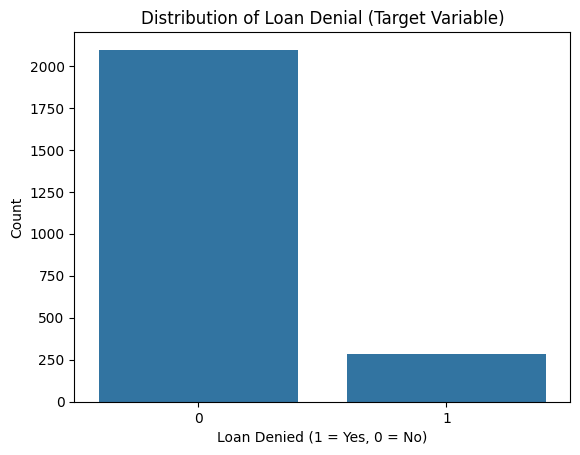

In [8]:
#Target variable overview
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='deny', data=df)
plt.title("Distribution of Loan Denial (Target Variable)")
plt.xlabel("Loan Denied (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()


- Out of 2,381 applications, only 285 were denied (~12%) overall.
- The target variable DENY is moderately imbalanced because a smaller proportion of applications were denied and accepted
- We'll have to use stratified sampling later to ensure balanced training and testing sets.


###**Histogram for Numeric Features**

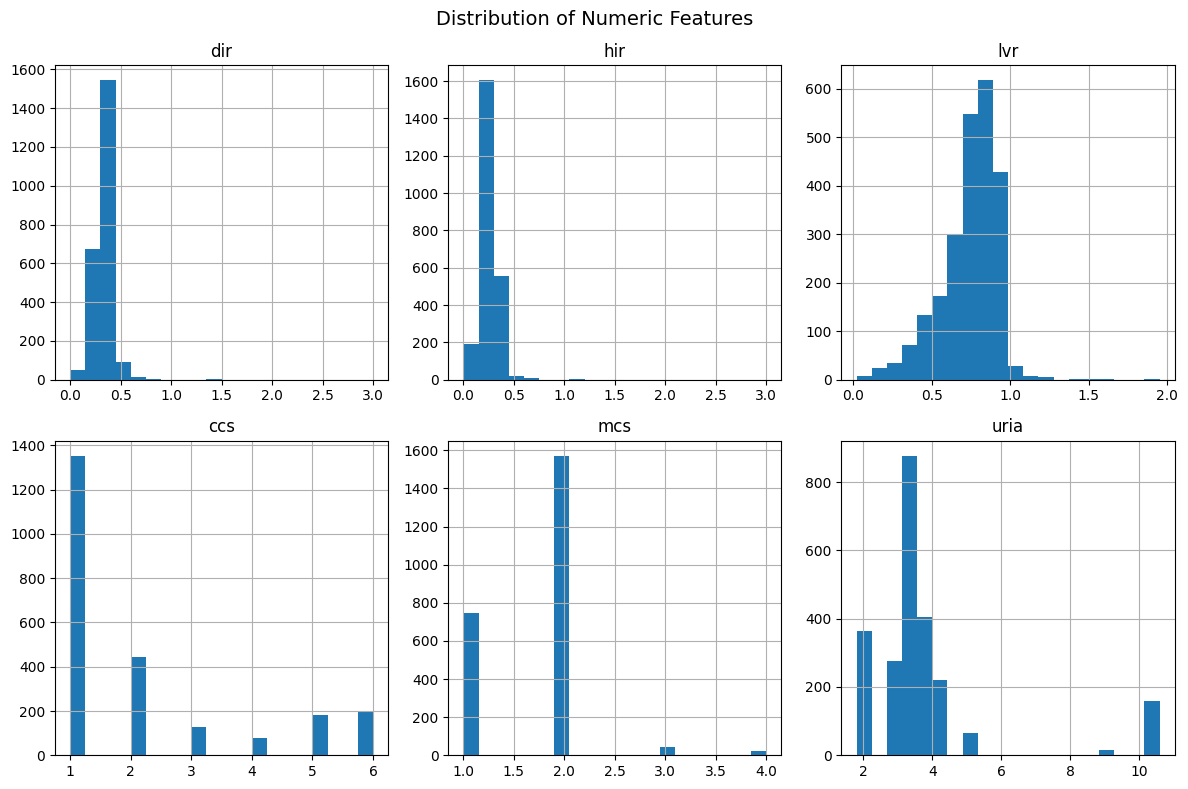

In [9]:
#Histograms for numeric variables
numeric_cols = ['dir', 'hir', 'lvr', 'ccs', 'mcs', 'uria']
df[numeric_cols].astype(float).hist(bins=20, figsize=(12, 8), layout=(2, 3))
plt.suptitle("Distribution of Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()


- Several numeric variables, such as debt-to-income (dir) and loan to value (lvr), appear to be rightskewed. They also seem to have some outliers.
- These skewed distributions may affect modeling negatively
- We may need to perform log transformations or scaling during data preparation if needed.


###**Correlation Matrix**

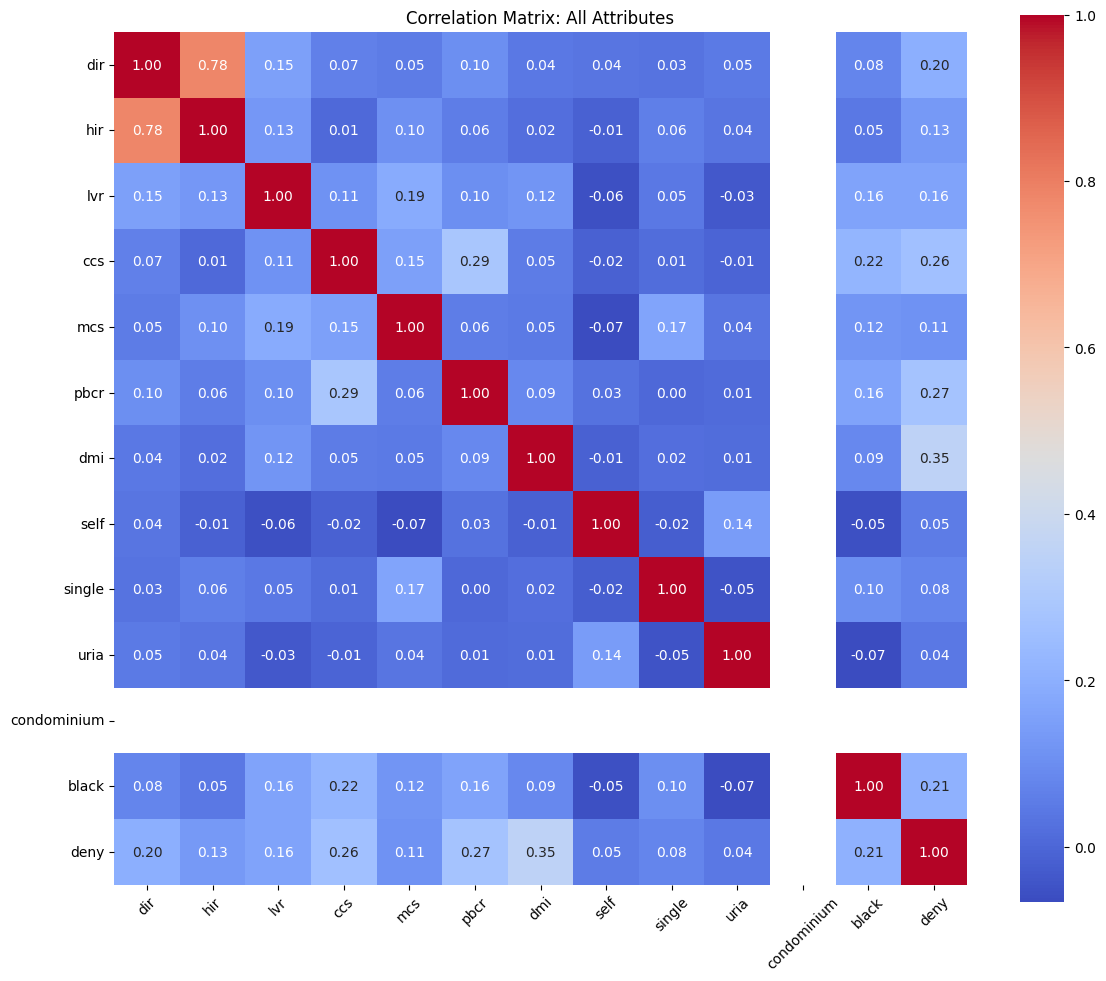

In [12]:
#Convert all columns to float to make EDA easier
df_corr = df.astype(float)

#Correlation matrix
corr_all = df_corr.corr()

#Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_all, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix: All Attributes")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


- The strongest correlation with deny is found in public bad credit record (pbcr), which means that bad credit history is a common cause of denial.

- loan to value (lvr) and debt to ratio (dir) are moderately correlated, but the overall multicollinearity appears low.

- There is also some moderate correlation between consumer credit score (ccs) and public bad credit score (pbcr), each with black applicants.

- There is also a correlation between black applicatants and denied loans

- As of now, we can't be sure if an increased rate of poor credit issues or race itself factor into mortgage denials. It is possible that both factor.


In [15]:
# Replace NaN values with 0.0 (not a condo)
df['condominium'] = df['condominium'].fillna(0)

# Convert all values to float (0.0 or 1.0)
df['condominium'] = df['condominium'].astype(float)

# Confirm result
print("Unique values in 'condominium':", df['condominium'].unique())
print("Data type:", df['condominium'].dtype)
print("Missing values:", df['condominium'].isna().sum())


Unique values in 'condominium': [0.]
Data type: float64
Missing values: 0


There is a problem with the condominum column, which we will try to fix by transforming it from current values to float binary



###**Closer Look at Denial Rate by Each Attribute**

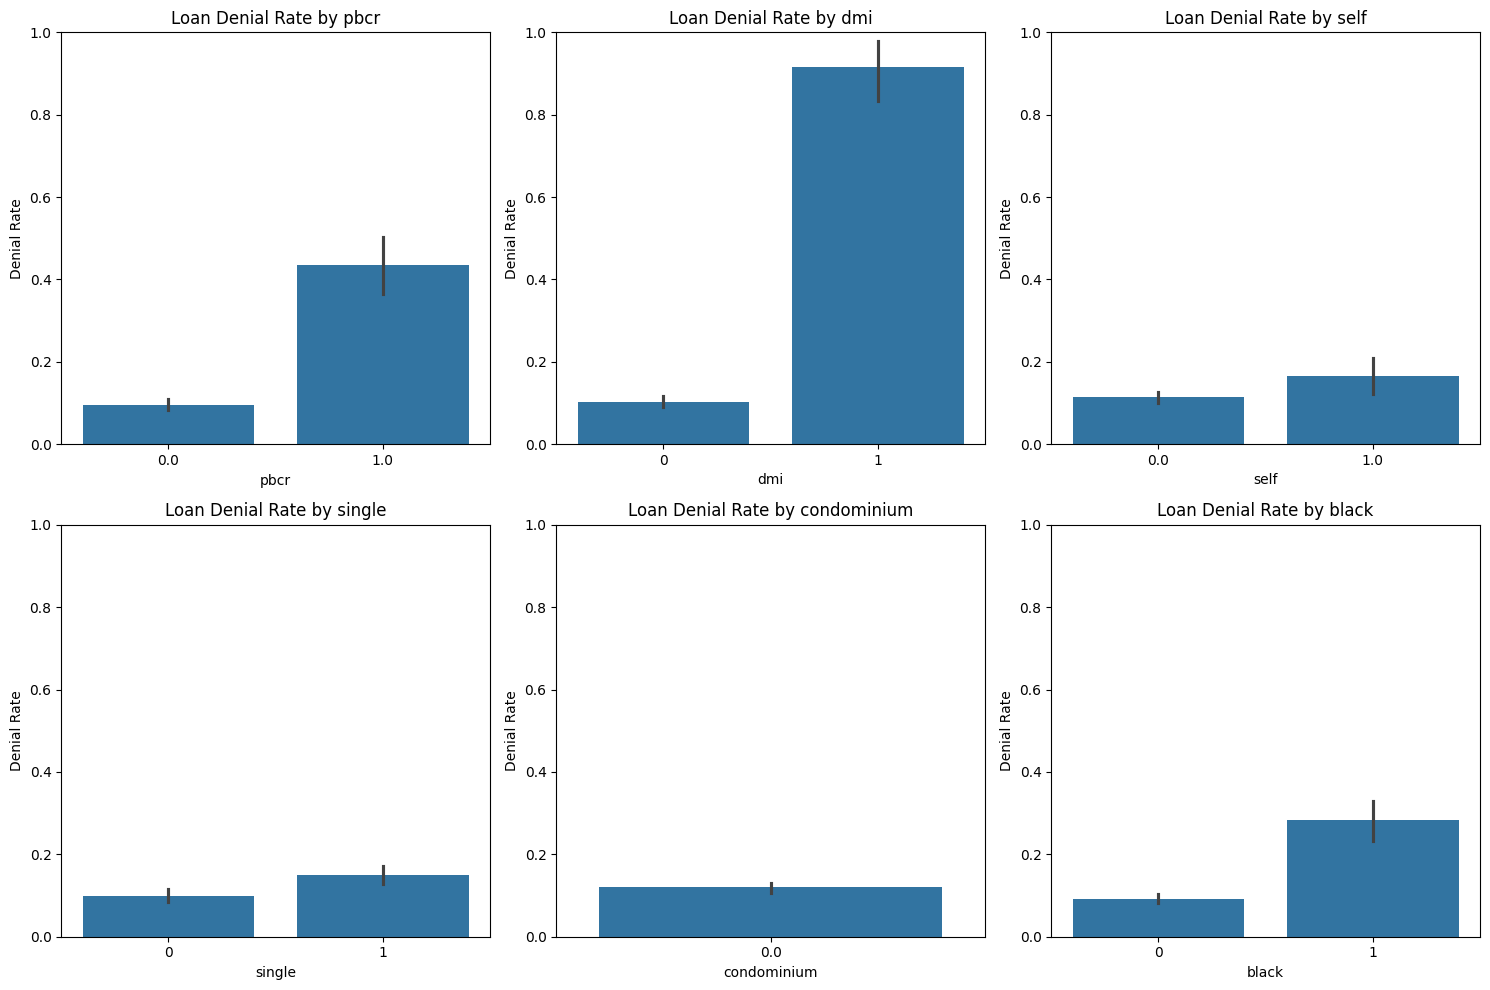

In [18]:
# Bar plots showing denial rates by binary features
binary_cols = ['pbcr', 'dmi', 'self', 'single', 'condominium', 'black']

plt.figure(figsize=(15, 10))
for i, col in enumerate(binary_cols, 1):
    plt.subplot(2, 3, i)
    sns.barplot(x=col, y='deny', data=df)
    plt.title(f'Loan Denial Rate by {col}')
    plt.ylim(0, 1)
    plt.ylabel("Denial Rate")

plt.tight_layout()
plt.show()


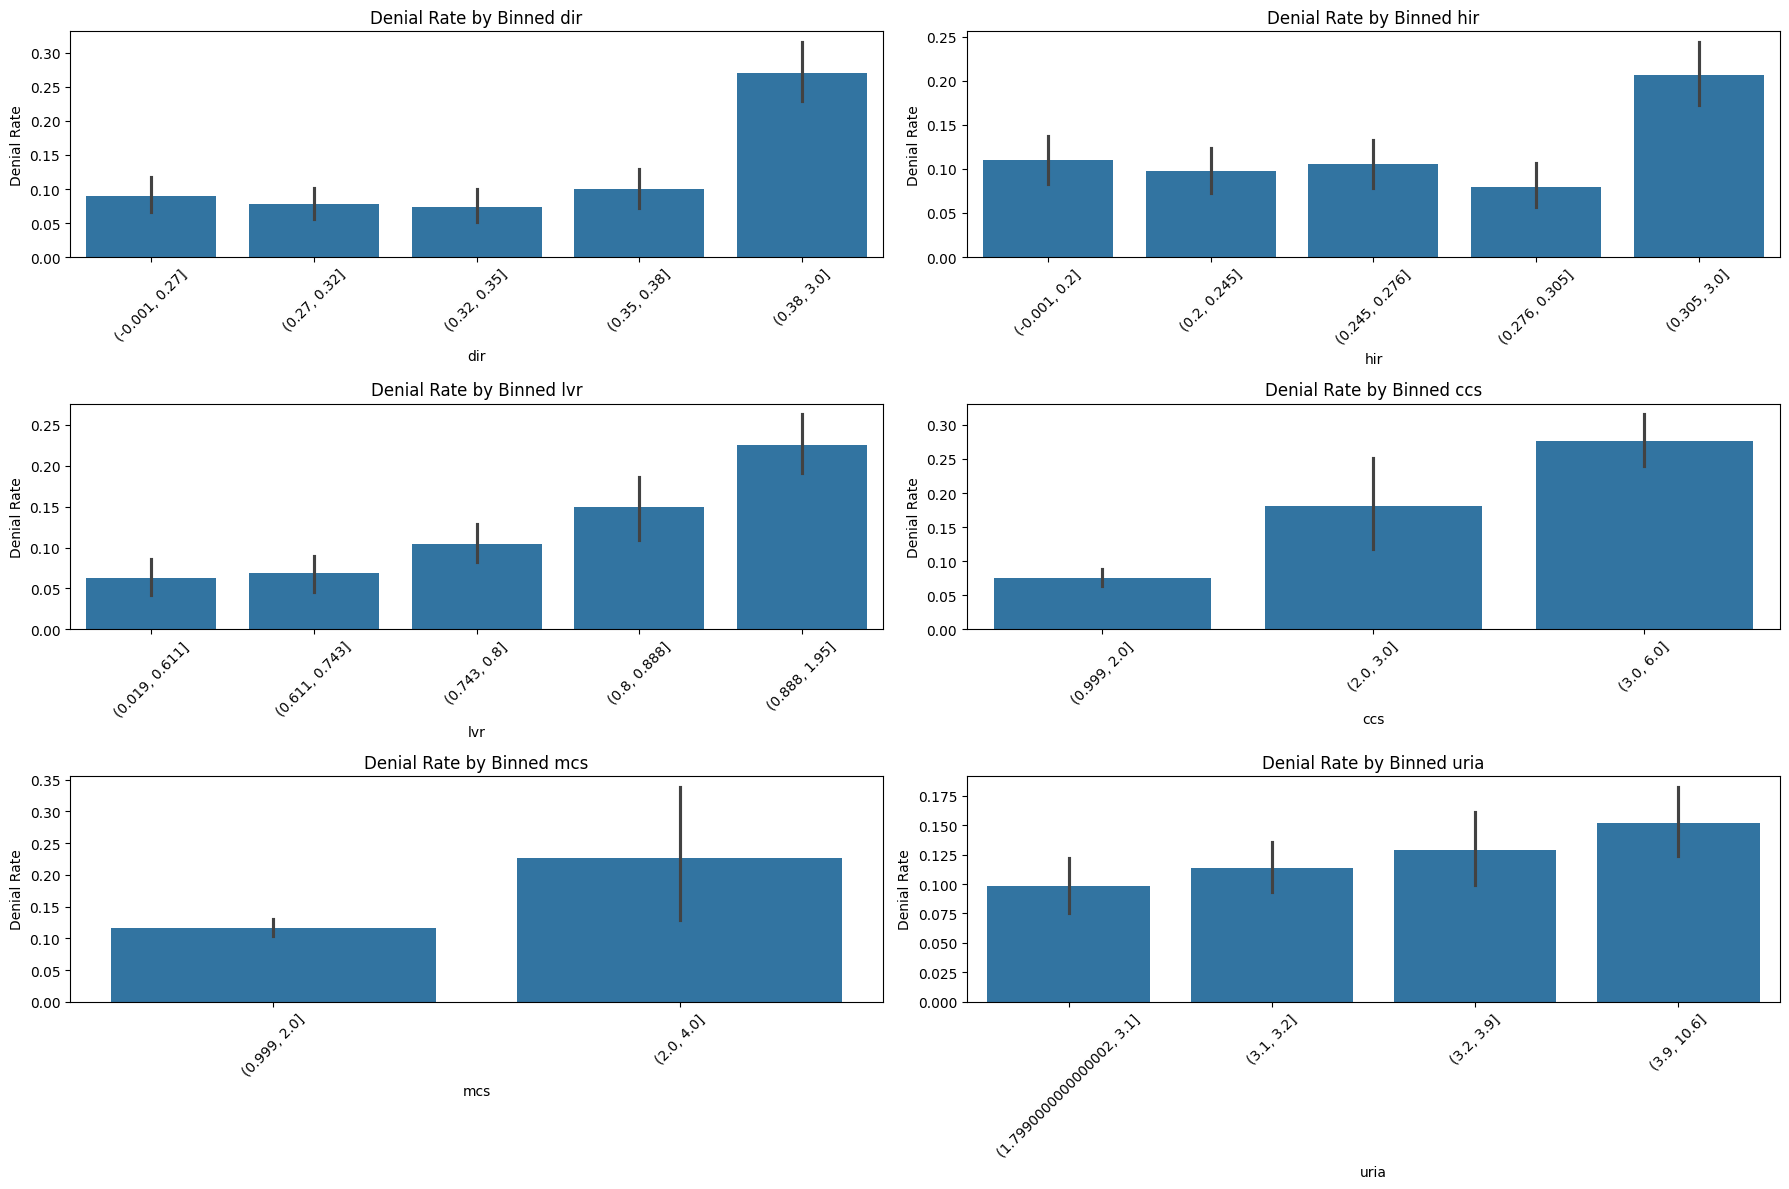

In [20]:
# Binned numeric variables vs average denial rate
import numpy as np

numeric_cols = ['dir', 'hir', 'lvr', 'ccs', 'mcs', 'uria']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    # Create 5 bins for each numeric feature
    df['bin'] = pd.qcut(df[col], q=5, duplicates='drop')
    sns.barplot(x='bin', y='deny', data=df)
    plt.xticks(rotation=45)
    plt.title(f'Denial Rate by Binned {col}')
    plt.ylabel('Denial Rate')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

# Remove temporary 'bin' column
df.drop(columns='bin', inplace=True)


To take a closer look at how every aatribute factors into denial rates, we can look at histograms of Denials (1) vs Approvals (0)
- Bad credit history (pbcr) has a significant effect on increased chance of denial
- Self Employment and Single status also increase the chance of denial, but not by as much.
- It is also clear that Black applicants are more often denied than not, which may indicate a racial bias when compared to the first histogram.

We binned the numeric attributes across divided sections to better evaluate them
- Denial rates are higher in the upper bins of debt-to-income (dir) and loan-to-value (lvr), suggesting financial risk increases rejection.
- Applicants with higher credit scores (ccs and mcs) tend to have lower denial rates.
- These patterns support including these features in our logistic regression models.

###**Distribution of Loan Value by Denial Status**

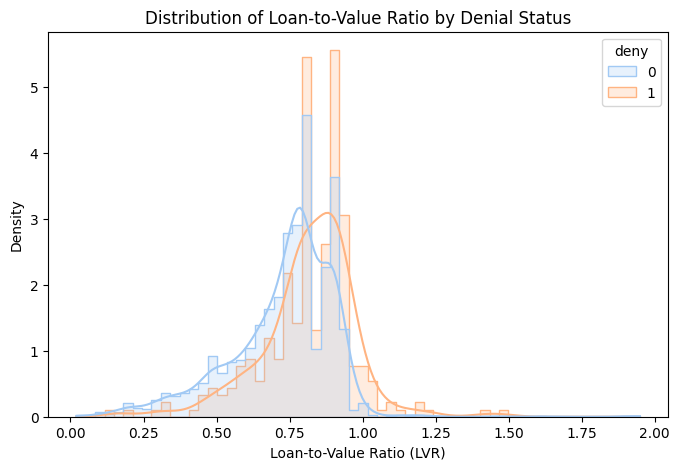

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x='lvr',
    hue='deny',
    kde=True,
    element='step',
    stat='density',
    common_norm=False,
    palette='pastel'
)
plt.title("Distribution of Loan-to-Value Ratio by Denial Status")
plt.xlabel("Loan-to-Value Ratio (LVR)")
plt.ylabel("Density")
plt.show()


We've determined that race, cedit history, and lifestyle factors like marital status and employment all have effects on mortgage approval rate.

The size of the mortgage may be another factor in denial. To study this, we plot a distribution of Loan-to-Value Ration by Denial.

The graph reflects the proportion of the home's value being financed and this graph shows that larger loans are slightly more likely to be denied, but the size of the loan does not have as big of an impact as other factors.

###**BloxPlot for Outlier Check**

#**Data Preperation**


###**Final Data Cleaning**

The Condominium column is still not working properly, so we have to fix it to make sure it refelcts float binary numbers and not NaN or anything else.

In [30]:
numeric_cols = ['dir', 'hir', 'lvr', 'ccs', 'mcs', 'uria']
binary_cols  = ['pbcr', 'dmi', 'self', 'single', 'condominium', 'black']

# --- 3.2  Fix the condominium column (NaN→0.0, else→1.0 as float) ---
df['condominium'] = (
    df['condominium']
    .fillna(0)          # NaN → 0
    .astype(float)
    .apply(lambda x: 1.0 if x != 0 else 0.0)
)

df.head()

,dir,hir,lvr,ccs,mcs,pbcr,dmi,self,single,uria,condominium,black,deny
0,0.182047,0.182047,1.147402,1.026672,2.0,0.0,0,0.0,0,0.951363,0.0,0,0
1,0.211129,0.211129,1.107944,0.741276,2.0,0.0,0,0.0,1,0.889981,0.0,0,0
2,0.274802,0.200114,1.108431,0.526589,2.0,0.0,0,0.0,0,0.889981,0.0,0,0
3,0.245008,0.201424,1.128021,0.526589,2.0,0.0,0,0.0,0,0.981219,0.0,0,0
4,0.268105,0.262445,1.208960,0.526589,1.0,0.0,0,0.0,0,0.889981,0.0,0,0


###**Transform Skew**

There was a slight right skew in some distrubtions that may negatively effect the results if they are significant enough.

In [28]:
import numpy as np
from scipy.stats import skew

#Skew Fix Function
def skew_fix(series):
    """Return transformed series to reduce |skew| if skew is strong."""
    s   = series.astype(float)
    sk  = skew(s.dropna())
    if sk > 0.5:                       # right-skewed
        return np.log1p(s)
    elif sk < -0.5:                    # left-skewed
        refl = s.max() + 1 - s         # reflect, keep ≥0
        return np.log1p(refl)
    else:                              # already roughly symmetric
        return s

#Apply transformation
for col in numeric_cols:
    df[col] = skew_fix(df[col])

#Confirm results
print("Skew after transformation:")
print(df[numeric_cols].apply(lambda s: skew(s.dropna())).round(2))
print("\nUnique condo values & dtype:", df['condominium'].unique(), df['condominium'].dtype)


Skew after transformation:
dir     0.99
hir     0.70
lvr     0.11
ccs     0.86
mcs     0.24
uria    0.90
dtype: float64

Unique condo values & dtype: [0.] float64


###**Correcting Outliers**

Logistic regression is sensitive to extreme values and our distribution plots showed we have some outliers.

To reduce the influence of these outliers, we apply winsorization to numeric features, which would make:

- Values below the 1st percentile set to the 1st percentile  
- Values above the 99th percentile set to the 99th percentile  

This method preserves all rows but prevents a few extreme values from skewing model coefficients.

In [29]:
#Clip outliers for numeric columns using 1st and 99th percentiles
for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

#Confirm updated ranges
df[numeric_cols].describe().T[['min', 'max']]


,min,max
dir,0.099266,0.382691
hir,0.056277,0.325300
lvr,1.070903,1.321783
ccs,0.526589,1.080418
mcs,1.000000,3.000000
uria,0.707848,1.238666


###**Prepped Data Review**

###**Histograms to check for Skew and Outliers**

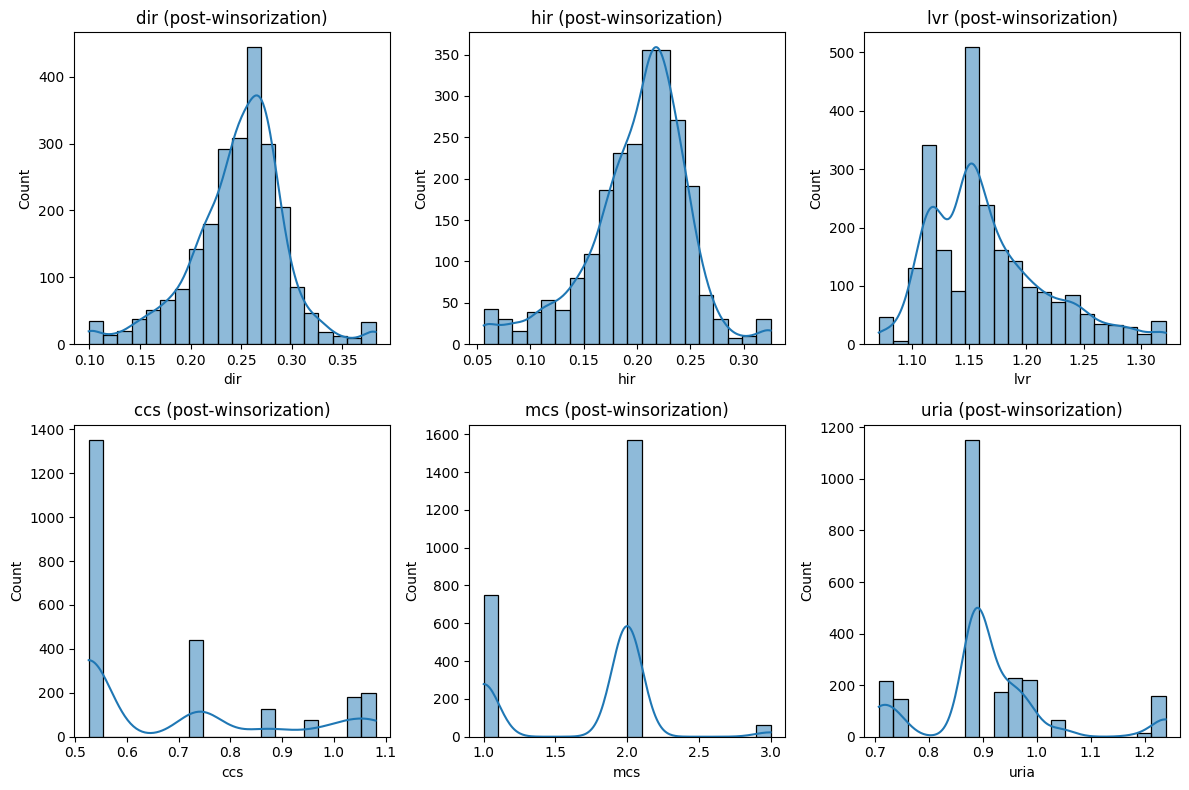

In [32]:
# Recheck distributions after winsorization and scaling transformation
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'{col} (post-winsorization)')
plt.tight_layout()
plt.show()


The distribution for most of the histograms look less skewed and seem to have less outliers, implying that the winsorization and scaling transformation were beneficial.

Running our models will let us know for sure if we did it correctly.

###**Correlation Map to Check Integrity of Conominium Variable**

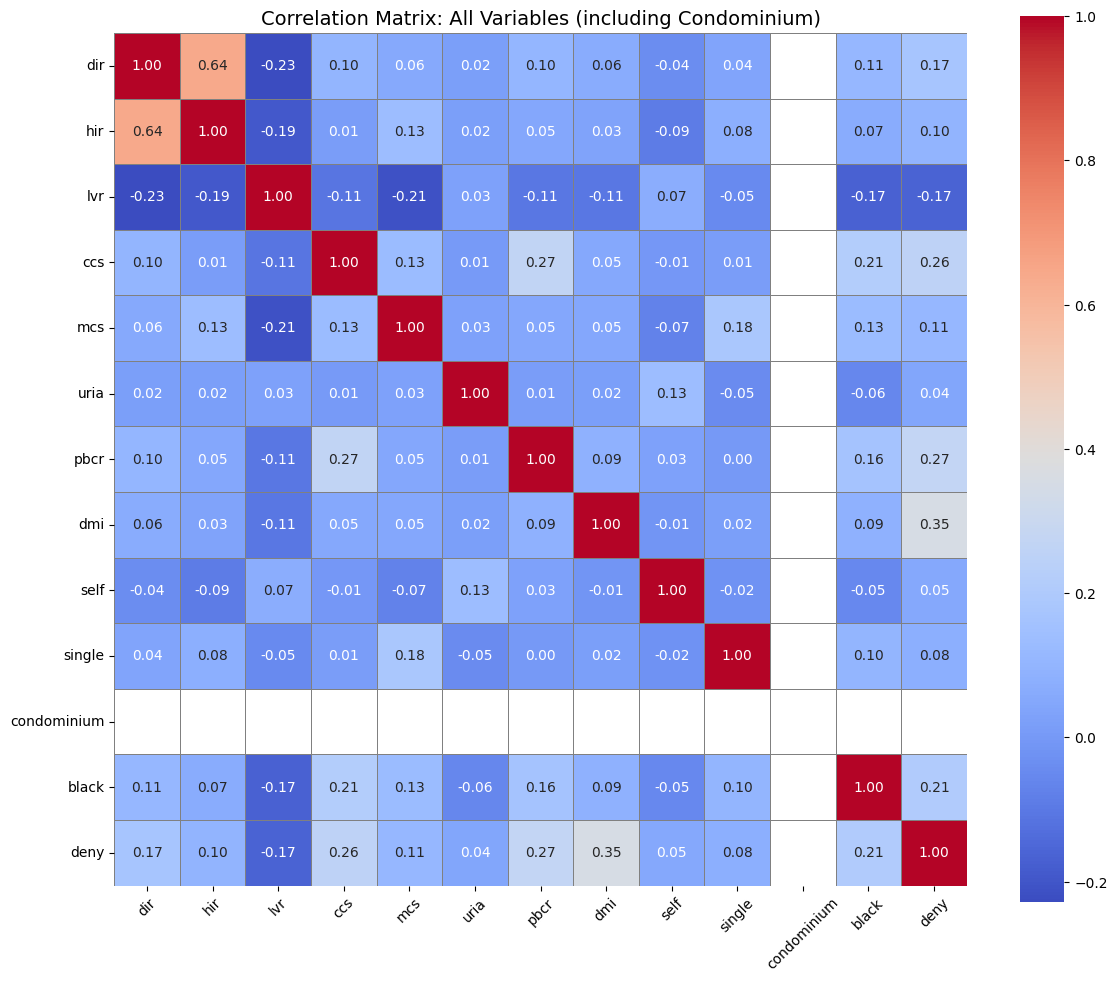

In [31]:
# Full correlation matrix including numeric and binary features
df_corr_all = df[numeric_cols + binary_cols + ['deny']].astype(float)

# Compute correlation matrix
corr_matrix = df_corr_all.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True,
            linewidths=0.5, linecolor='gray')
plt.title("Correlation Matrix: All Variables (including Condominium)", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


After out first few changes, we still have a problem with the Condominimum column.

A column with no variance would not show on the correlation matrix, so we do a check for variance:

In [33]:
#Check value counts and variance for condominium
print("Condominium value counts:")
print(df['condominium'].value_counts(dropna=False))

print("\nCondominium variance:", df['condominium'].var())


Condominium value counts:
condominium
0.0    2381
Name: count, dtype: int64

Condominium variance: 0.0


This means that every row has been accidentally set to zero.

There isn't a way to retrieve the data at this point and rather than attempting to reconstruct this feature, we can drop it from the analysis entirely.  

The remaining features should be sufficient for our model.

In [39]:
df.drop(columns='condominium', inplace=True)
binary_cols.remove('condominium')


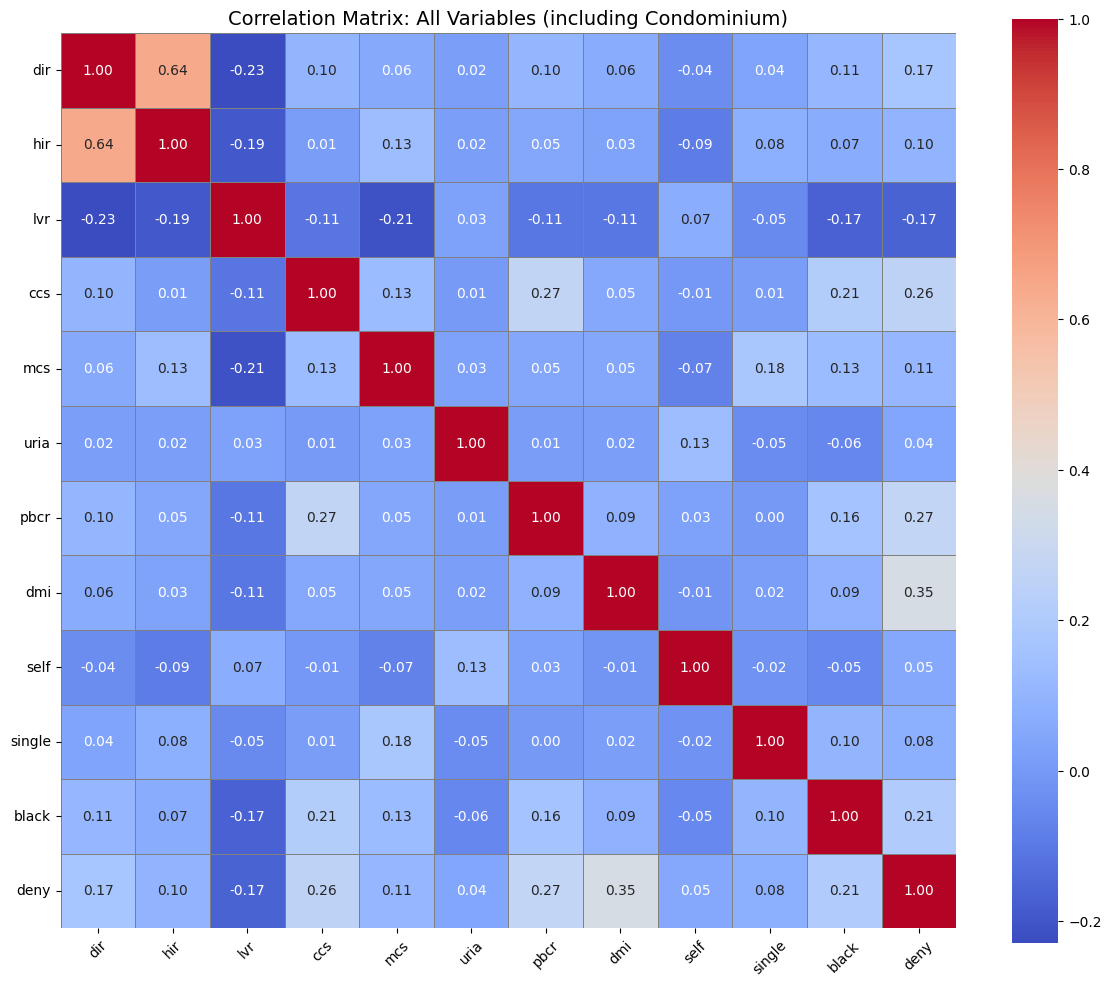

In [40]:
# Full correlation matrix including numeric and binary features
df_corr_all = df[numeric_cols + binary_cols + ['deny']].astype(float)

# Compute correlation matrix
corr_matrix = df_corr_all.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True,
            linewidths=0.5, linecolor='gray')
plt.title("Correlation Matrix: All Variables (including Condominium)", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [41]:
df.head()

,dir,hir,lvr,ccs,mcs,pbcr,dmi,self,single,uria,black,deny
0,0.182047,0.182047,1.147402,1.026672,2.0,0.0,0,0.0,0,0.951363,0,0
1,0.211129,0.211129,1.107944,0.741276,2.0,0.0,0,0.0,1,0.889981,0,0
2,0.274802,0.200114,1.108431,0.526589,2.0,0.0,0,0.0,0,0.889981,0,0
3,0.245008,0.201424,1.128021,0.526589,2.0,0.0,0,0.0,0,0.981219,0,0
4,0.268105,0.262445,1.208960,0.526589,1.0,0.0,0,0.0,0,0.889981,0,0


The Condominium column has been successfully dropped.

#**Regression Modeling**

We will train three logistic regression models using different sets of features to try and evaluate the effect of potential descrimination in the mortage approval process.

1. **Model 1: Baseline**: Uses only affordability variables
  - Debt-to-Income Ratio (dir)
  - Housing-Income Ratio (hir)
  - Loan-to-Value Ratio (lvr)
2. **Model 2: Credit**: Adds credit history information  
  - Consumer Credit Score (ccs)
  - Mortgage Credit Score (mcs)
  - Public Bad Credit Record (pbcr)
3. **Model 3: Full**: Adds remaining variables  
  - insurance (dmi)
  - employment (self)
  - marital status (single)
  - race (black)

Model 1 will evaluate how Debt-to-Income Ratio, Housing-Income Ratio, and Loan-to-Value Ratio alone affect the denial rate. These are the core affordability metrics that reflect whether a borrower can reasonably pay back the loan based on their income and the size of the loan. It answers whether or not loans are according to basic cost alone. Using this model as a baseline will allow us to compare how other factors effect denial rates.  

In our previous analysis we found that other than race, the biggest possible reason for a loan being denied is a bad credit history. We need to isolate the impact of credit history from other demographics features that may fall under discrimniation, so that we can figure out if any discrimination is taking place. We will add Consumer Credit Score, Mortgage Credit Score, and Public Bad Credit Record to the baseline model to create Model 2.

Finally, Model 3 will evalute how the remaining demographic features effect denial rate. These features include race, employment, and marital status. Dmi is also included in this model because it would reflect discrimination, if any exists. This model will let us know if even after accounting for affordability and credit, are social and demographic factors still influencing denial decisions?


All models are trained with cross-validation and their coefficients will be interpreted to assess whether predictors behave as expected and whether sensitive features like race contribute meaningfully to prediction


Creating the 3 features groups:

In [42]:
#Define feature groups
baseline_features = ['dir', 'hir', 'lvr']
credit_features   = baseline_features + ['ccs', 'mcs', 'pbcr']
full_features     = credit_features + ['dmi', 'self', 'single', 'black']


We will use a pipeline to run the three models,to ensure identical preprocessing inside each CV fold. This avoids data leakage and ensures that no other uncontrolled factors are affecting each model.

In [46]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

#Declare all Feature except Condo
numeric_cols = ['dir', 'hir', 'lvr', 'ccs', 'mcs', 'uria']
binary_cols  = ['pbcr', 'dmi', 'self', 'single', 'black']   #condo dropped

#Declare the 3 sets of Features for each model
baseline_features = ['dir', 'hir', 'lvr']
credit_features   = baseline_features + ['ccs', 'mcs', 'pbcr']
full_features     = credit_features   + ['dmi', 'self', 'single', 'black']

#Extract target vector, DENY
y = df['deny'].astype(int)           # make sure it's int/0-1

#Helper function to build a pipeline for any feature set
def build_pipeline(features):
    num_cols = [f for f in features if f in numeric_cols]
    bin_cols = [f for f in features if f in binary_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            #use scalar and median imputer again to fix issue
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler' , StandardScaler())
            ]), num_cols),
            #add median imputers to drop any missed values that were not caught
            ('bin', SimpleImputer(strategy='most_frequent'), bin_cols)
        ],
        remainder='drop'   #only keep the specified columns
    )
    #run 3 models at once with the pipeline
    pipe = Pipeline([
        ('prep', preprocessor),
        ('logreg', LogisticRegression(max_iter=1000))
    ])
    return pipe

#Cross-validate the three models
models_info = []
for name, feats in zip(
        ['Baseline', 'Credit', 'Full'],
        [baseline_features, credit_features, full_features]):

    pipe = build_pipeline(feats)
    cv_scores = cross_val_score(pipe,
                                df[feats],  # X
                                y,           # y
                                cv=5,
                                scoring='roc_auc',
                                n_jobs=-1)

    models_info.append({
        'Model'       : name,
        'Feature count': len(feats),
        'ROC-AUC mean': cv_scores.mean(),
        'ROC-AUC std' : cv_scores.std()
    })

display(pd.DataFrame(models_info))


,Model,Feature count,ROC-AUC mean,ROC-AUC std
0,Baseline,3,0.695116,0.034103
1,Credit,6,0.774261,0.016661
2,Full,10,0.813833,0.033632


#**Evaluation and Selecting A Model**

###**Selection**

In these models, the **ROC-AUC** mean reflects the probability that the model ranks a randomly chosen denied application higher than an approved one. A score of 1.00 would indicate perfect discrimination and a lower score reflects better chances of the loan being approved.

We can see that based on affordibility alone (from Model 1), there is a good rate of prediction at **0.69.**

When Credit History is taken into accout, Model 2 results show that the accuracy increases to **0.77**. This is to be expected from our previous evaluations of the data, and is morally fair because a bad credit history indicates a higher risk for the bank.

When the remaining demographic factors are added however, the prediction rate increases to **0.81**, which shows that some discrimination is likely taking place. However, it is not clear if the discrimination is due to race, employment, or maritial status. The Dmi variable may also be artificially inflating the number, as it is not possible to seperate it as a pure demographic feature.

Our evaluation of this model taken with the previous evalution of the data itself indicates that most likely, some dicrimnination is taking place. Models 1 and 2 that don't take demographics into account are therefor not as accurate in prediction denial rates.

The Bank has tasked us to create a model that most accurately predicts denial rates and **Model 3** most accurate. When using this model, bank employees should be aware that there are some demographic biases invloved in race, marital status, or employment, and judge the case accordingly to correct for bias.

###**Apply Model 3 to Testing Subset**

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay

# Split data
X_full = df[full_features]
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.3, stratify=y, random_state=42)

# Build and fit final model
pipe = build_pipeline(full_features)
pipe.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['dir', 'hir', 'lvr', 'ccs',
                                                   'mcs']),
                                                 ('bin',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['pbcr', 'dmi', 'self',
                                                   'single', 'black'])])),
                ('logreg', LogisticRegression(max_iter=1000))])

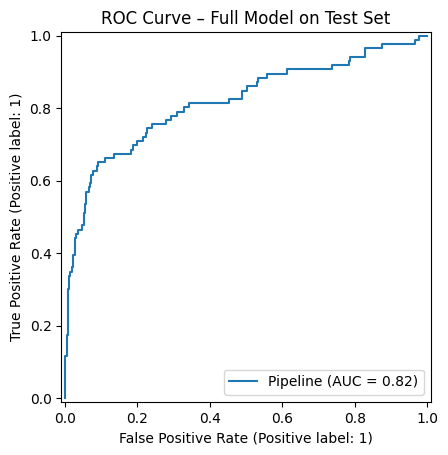

In [48]:
# ROC curve on hold-out test set
RocCurveDisplay.from_estimator(pipe, X_test, y_test)
plt.title("ROC Curve – Full Model on Test Set")
plt.show()


The ROC curve for Model 3 shows how well it separates denied vs approved applications.

The curve bows significantly upward, confirming good predictive power. The area under the curve also confirms the earlier cross-validation value (~0.81)

This confirms that even after accounting for affordability and credit, demographic and structural variables effect predictive accuracy. It may contain potential bias that regulators should interpret carefully.


#**Conclusion**
In this project, we explored a publicly available dataset on mortgage applications to investigate whether patterns of potential discrimination may still exist in modern lending practices. We developed and compared three logistic regression models that predict whether a mortgage application is likely to be denied based on a variety of features. Model performance was evaluated using cross-validated ROC-AUC scores.

We found that each successive model improved in predictive ability, with the Full Model (Model 3) achieving the highest ROC-AUC score. Comparing our results showed that while credit history justifiably has a big impact on the chance of loans being approved or denied, demographic data also has a big impact. The result from these model along with the results of our EDA analysis indidate that at least some racial bias does likely exist in the mortgage loan industry.

Although our chosen model integrates these biases, it can provide strong predictive power and insight into lending decisions. Lenders shouldn't use this model to decide on whether or not to give a loan, but they can use it to detect potential systemic biases in their process and use more care when making their decisions.


